In [6]:
import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
import scipy
from scipy.sparse import issparse

# single cell tools
import scanpy as sc
import squidpy as sq
from anndata import AnnData

In [7]:
FOLDER = "legnini23"
GEX_DATA = "legnini23_None_sample_1_44"

In [8]:
from graph_transformer_long_range_niches.tl import pad_batch, load_model
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, FIG_PATH, LEGNINI23

In [9]:
RESULTS = Path(RESULTS, 'legnini23')

In [10]:
SHH_MARKERS = ["FOXA1", "FOXA2", "NKX2.2", "MNX1", "OLIG1", "OLIG2", "NKX6.2", "NKX6.1", "NEUROG2", "NEUROD1", "PAX6", "IRX3", "OTP", "OTX2", "DBX2", "DBX1"]

# Basline 

In [66]:
model_transformer_gex, cfg_gex, obs_gex = load_model(GEX_DATA, model_type = "gnn-transformer")

num features: 88


In [67]:
adata = sc.read_h5ad(Path(LEGNINI23))
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'raw'

In [68]:
sample_id_ctrl = 'slide4_A2-3'
sample_id_shh = 'slide4_B2-2'

## Spatially variable genes

In [69]:
cfg = cfg_gex

category_to_iterate_list = cfg.dataset.library_key
spatial_neigbors_kwargs = cfg.dataset.spatial_neigbors_kwargs

In [70]:
spatial_neigbors_kwargs

CfgNode({'radius': 200, 'coord_type': 'generic', 'library_key': 'sample'})

In [71]:
sq.gr.spatial_neighbors(
    adata,
    radius=spatial_neigbors_kwargs.radius,
    coord_type=spatial_neigbors_kwargs.coord_type,
    library_key = spatial_neigbors_kwargs.library_key
)

In [72]:
sub_adata_ctrl = adata[adata.obs['sample'] == sample_id_ctrl]
sub_adata_shh = adata[adata.obs['sample'] == sample_id_shh]

In [73]:
sq.gr.spatial_autocorr(sub_adata_ctrl, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(sub_adata_shh, mode="moran", genes=adata.var_names)

In [74]:
for sub_adata in [sub_adata_ctrl, sub_adata_shh]:
    top_genes = sub_adata.uns["moranI"][:20].index
    overlap = [gene for gene in top_genes if gene in SHH_MARKERS]
    print(f"{len(overlap)} Shh markers found (total: {len(SHH_MARKERS)}) - {overlap}")

5 Shh markers found (total: 16) - ['DBX2', 'PAX6', 'FOXA2', 'IRX3', 'FOXA1']
12 Shh markers found (total: 16) - ['FOXA2', 'FOXA1', 'DBX1', 'PAX6', 'DBX2', 'IRX3', 'NKX6.1', 'OTP', 'OLIG2', 'NKX2.2', 'MNX1', 'NKX6.2']


In [75]:
sample_ids_shh = np.unique(adata[adata.obs['condition'] == 'SHH'].obs['sample'])
sample_ids_ctrl = np.unique(adata[adata.obs['condition'] == 'Ctrl'].obs['sample'])

In [76]:
results = []

for top_n in [5, 10, 15, 20]:
    for sample_ids, condition in [(sample_ids_ctrl, 'ctrl'), (sample_ids_shh, 'shh')]:
        nr_overlap = []
        for sample_id in np.unique(sample_ids):
            sub_adata = adata[adata.obs['sample'] == sample_id]
            sq.gr.spatial_autocorr(sub_adata, mode="moran", genes=sub_adata.var_names)
            top_genes = sub_adata.uns["moranI"][:top_n].index
            overlap = [gene for gene in top_genes if gene in SHH_MARKERS]
            nr_overlap.append(len(overlap))
        avg_overlap = np.mean(nr_overlap)
        results.append({'condition': condition, 'Top_n': top_n, 'Avg_Overlap': avg_overlap})

# Convert results to a pandas DataFrame
df_results = pd.DataFrame(results)
df_results.to_csv(Path(RESULTS, 'shh_markers_morans.csv'))

print(df_results)    

  condition  Top_n  Avg_Overlap
0      ctrl      5     1.833333
1       shh      5     3.454545
2      ctrl     10     3.666667
3       shh     10     5.636364
4      ctrl     15     5.166667
5       shh     15     6.909091
6      ctrl     20     5.833333
7       shh     20     8.181818


## Baseline model: Implementation

In [83]:
class baseline:

    def __init__(self, adata):
        self.adata = adata
        conn = self.adata.obsp['spatial_connectivities']
        conn = conn + scipy.sparse.csr_matrix(np.eye(conn.shape[0]))
        conn = conn.multiply(1/conn.sum(axis=1))
        self.adata.layers['aggregated'] = conn @ self.adata.X
        self.adata.X = self.adata.layers['aggregated']

    def eval(self, sample_id, return_data: bool = False, plot: bool = False):
        sub_adata = self.adata[self.adata.obs['sample'] == sample_id]
        sc.pp.neighbors(sub_adata, n_neighbors = 40, use_rep='X')
        sc.tl.leiden(
            sub_adata,
            resolution=0.3,
            use_weights=True,
            key_added='leiden'
        )
        clusters = sub_adata.obs['leiden']
        if plot:
            sq.pl.spatial_scatter(
                sub_adata,
                library_key = spatial_neigbors_kwargs.library_key,
                img=False,
                color= 'leiden',
                size=10,
                shape = None,
            )
        sc.tl.rank_genes_groups(sub_adata, groupby='leiden', method='wilcoxon', key_added = 'dge_wilcoxon')
        if plot:
            sc.pl.rank_genes_groups_dotplot(
                sub_adata,
                groupby="leiden",
                standard_scale="var",
                n_genes=5,
                key="dge_wilcoxon",
            )
        if return_data:
            return sub_adata

In [84]:
baseline = baseline(adata)

In [89]:
sub_adata_ctrl = baseline.eval(sample_id_ctrl, return_data = True)

In [90]:
sub_adata_shh = baseline.eval(sample_id_shh, return_data = True)

### Overlapping marker genes

How many genes does the leiden clustering identify as significant?

In [11]:
def overlapping_marker_genes(adata, markers_list, dge_key: str = 'dge_wilcoxon', top_n: int = 10):
    # Extract rank_genes_groups result
    ranked_genes = adata.uns[dge_key]['names']  # 2D array (clusters x genes)
    
    # Initialize a dictionary to store marker overlaps for each cluster
    overlap = set()
    
    # Loop through each cluster's ranked genes
    for idx in range(top_n):
        top_genes = ranked_genes[idx]
        
        # Find the overlap with Shh markers
        overlap.update([gene for gene in top_genes if gene in markers_list])
    
    print(f"{len(overlap)} Shh markers found (total: {len(markers_list)}) - {overlap}")
    return overlap

In [12]:
overlapping_marker_genes(sub_adata_ctrl, SHH_MARKERS, dge_key = 'dge_wilcoxon', top_n = 10)
overlapping_marker_genes(sub_adata_shh, SHH_MARKERS, dge_key = 'dge_wilcoxon', top_n = 10)


KeyboardInterrupt



In [ ]:
results = []

for top_n in [5, 10, 15, 20]:
    for sample_ids, condition in [(sample_ids_ctrl, 'ctrl'), (sample_ids_shh, 'shh')]:
        nr_overlap = []
        for sample_id in np.unique(sample_ids):
            sub_adata = baseline.eval(sample_id, return_data = True)
            overlap = overlapping_marker_genes(sub_adata, SHH_MARKERS, dge_key = 'dge_wilcoxon', top_n = top_n)
            nr_overlap.append(len(overlap))
        avg_overlap = np.mean(nr_overlap)
        results.append({'condition': condition, 'Top_n': top_n, 'Avg_Overlap': avg_overlap})

# Convert results to a pandas DataFrame
df_results = pd.DataFrame(results)
df_results.to_csv(Path(RESULTS, 'shh_markers_baseline.csv'))

print(df_results)    

### Plot SHH marker gene detection comparison

In [33]:
def plot_marker_gene_detection(df):
    # Set the style of seaborn
    sns.set(style="whitegrid")

    # Adjust the context to increase font size
    sns.set_context("talk", font_scale=1)  # Adjust font_scale as needed
    
    # Create a FacetGrid for the conditions
    g = sns.FacetGrid(df, col="condition", sharey=True, height=5, aspect=1.2)
    
    # Map barplots to each condition subplot
    g.map_dataframe(sns.barplot, x="Top_n", y="Avg_Overlap", hue="method", ci=None)
    
    # Add titles and adjust
    g.set_axis_labels("Top N Genes", "Gene Overlap")
    g.set_titles("{col_name}")
    g.add_legend(title="Method")
    g.tight_layout()
    
    # Show the plot
    plt.show()

In [21]:
df_svg = pd.read_csv(Path(RESULTS, 'shh_markers_morans.csv'))
df_baseline = pd.read_csv(Path(RESULTS, 'shh_markers_baseline.csv'))
df_InterScale = pd.read_csv(Path(RESULTS, 'shh_markers_InterScale.csv'))

In [22]:
df_InterScale = df_InterScale.rename(columns = {'local_overlap': 'Avg_Overlap'})
df_InterScale = df_InterScale.drop(columns = ['global_overlap'])

In [23]:
df_svg['method'] = 'MoransI'
df_baseline['method'] = 'Baseline'
df_InterScale['method'] = 'InterScale'


# Combine them into one DataFrame
combined_df = pd.concat([df_svg, df_baseline, df_InterScale], ignore_index=True)

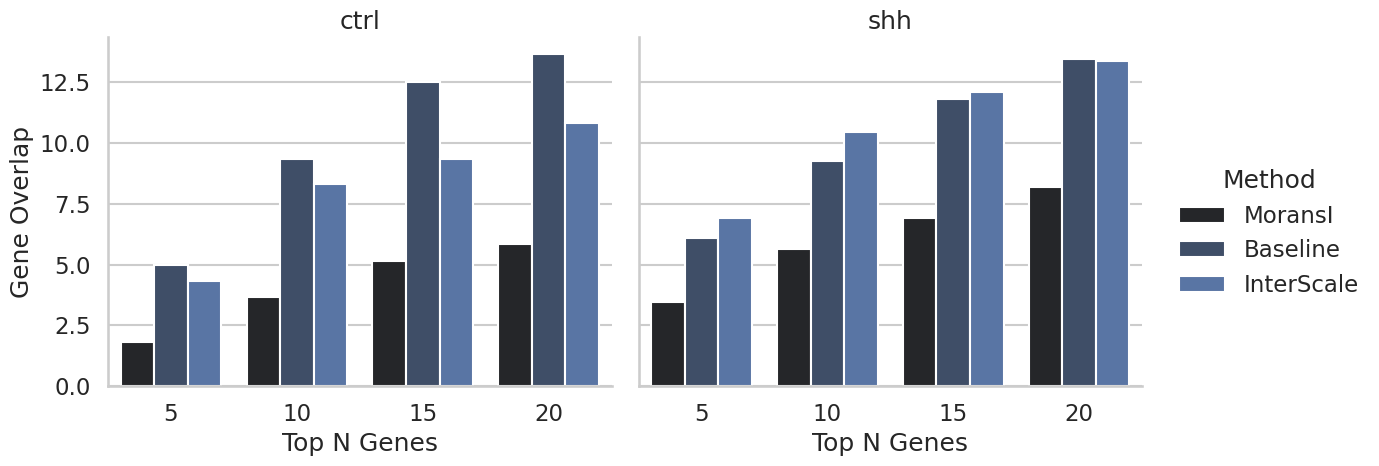

In [34]:
# InterScale local overlap
plot_marker_gene_detection(combined_df)

In [35]:
df_svg = pd.read_csv(Path(RESULTS, 'shh_markers_morans.csv'))
df_baseline = pd.read_csv(Path(RESULTS, 'shh_markers_baseline.csv'))
df_InterScale = pd.read_csv(Path(RESULTS, 'shh_markers_InterScale.csv'))
df_InterScale = df_InterScale.rename(columns = {'global_overlap': 'Avg_Overlap'})
df_InterScale = df_InterScale.drop(columns = ['local_overlap'])
df_svg['method'] = 'MoransI'
df_baseline['method'] = 'Baseline'
df_InterScale['method'] = 'InterScale'


# Combine them into one DataFrame
combined_df = pd.concat([df_svg, df_baseline, df_InterScale], ignore_index=True)

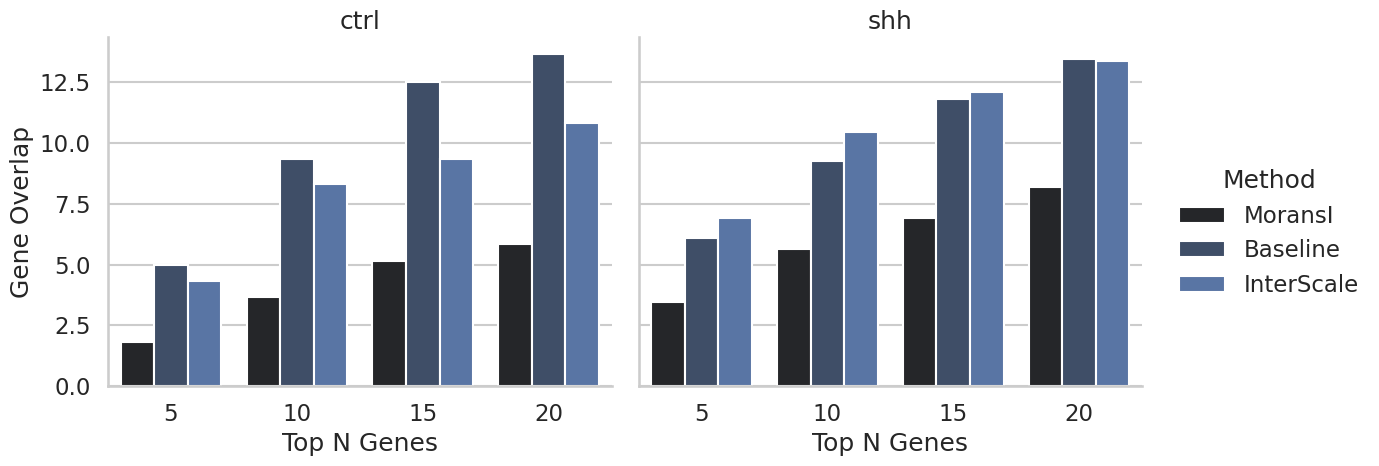

In [36]:
# InterScale global overlap
plot_marker_gene_detection(combined_df)